<a href="https://colab.research.google.com/github/suprajushivajji/Handwritten_Digit_Generator/blob/main/Handwritten_Digit_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow imageio tensorflow-docs

In [ ]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow.keras import layers
import time

from IPython import display

**Datasets adding**

In [ ]:
(train_images,train_labels),(_, _) = tf.keras.datasets.mnist.load_data()

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_images=train_images.reshape(train_images.shape[0],28,28,1).astype('float32')
train_images=(train_images-127.5)/127.5 #Normalize the image to[-1,1]

In [ ]:
BUFFER_SIZE=60000
BATCH_SIZE=256

In [ ]:
#Batch and shuffle the data
train_dataset=tf.data.Dataset.from_tensor_slices(train_images).shuffle(BATCH_SIZE).batch(BATCH_SIZE)

**Create a Model**

**Generator**

In [ ]:
def make_generator_model():
  model=tf.keras.Sequential()
  model.add(layers.Dense(7*7*256,use_bias=False,input_shape=(100,)))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Reshape((7,7,256)))
  assert model.output_shape==(None,7,7,256) #Note:None is batch Size

  model.add(layers.Conv2DTranspose(128,(5,5),strides=(1,1),padding='same',use_bias=False))
  assert model.output_shape==(None,7,7,128)
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(64,(5,5),strides=(2,2),padding='same',use_bias=False))
  assert model.output_shape==(None,14,14,64)
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())

  model.add(layers.Conv2DTranspose(1,(5,5),strides=(2,2),padding='same',use_bias=False,activation='tanh'))
  assert model.output_shape==(None,28,28,1)

  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


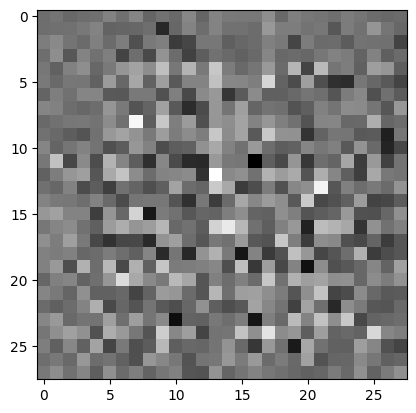

In [ ]:
#using the untrained generator to generate an image from random tasks
generator=make_generator_model()

noise=tf.random.normal([1,100])
generated_image=generator(noise,training=False)

plt.imshow(generated_image[0,:,:,0],cmap='grey')

**Discriminator**

In [ ]:
def make_discriminator_model():
  model=tf.keras.Sequential()
  model.add(layers.Conv2D(64,(5,5),strides=(2,2),padding='same',input_shape=[28,28,1]))

  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Conv2D(128,(5,5),strides=(2,2),padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Flatten())
  model.add(layers.Dense(1))

  return model

In [ ]:
#using the untrained discriminatior to predict wheather an image is real or fake
discriminator=make_discriminator_model()
decision=discriminator(generated_image)
print(decision)

tf.Tensor([[0.00039592]], shape=(1, 1), dtype=float32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Loss and Optimizer**

In [ ]:
#This method returns a helper function to compute cross entropy loss
cross_entropy=tf.keras.losses.BinaryFocalCrossentropy(from_logits=True)

**Discrimnator Loss**

This method quantifies how well the discriminator is able to distinguish real images from fakes.It compares the discriminator's predictions on real images to an array of 1's,and the discriminator's predictions on fake (generated) images to an array of 0s.

In [ ]:
def discriminator_loss(real_output,fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output),real_output)
  fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
  total_loss=real_loss+fake_loss
  return total_loss

**Generator Loss**

The generator's loss quantifies how well it was able to trick the discriminator.Intuitively,if the generator is performing well,the discriminator will classify the fake images as real(or 1). Here ,compare the discriminators decisions on the generated images to an arry of 1s

In [ ]:
def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output),fake_output)
# The error is not in this cell. Please execute cell OoLLwfQcDkiv to define the optimizers
# and then re-execute cell NP6h67WDD2jk to fix the NameError.

The discriminator and the generator optiizers are different since we will train two networks separately.

In [ ]:
generator_optimizer=tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer=tf.keras.optimizers.Adam(1e-4)

**Saving the Checkpoints**

In [ ]:
checkpoint_dir='./training_checkpoints'
checkpoint_prefix=os.path.join(checkpoint_dir,"ckpt")
checkpoint=tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                               discriminator_optimizer=discriminator_optimizer,
                               generator=generator,
                               discriminator=discriminator)

**Defining the training loop**

In [ ]:
EPOCHS=100
noise_dim=100
num_examples_to_generate=16

#You will reuse this seed overtime (so its easier)
#To visualize progress in the animated gif)
seed=tf.random.normal([num_examples_to_generate,noise_dim])

The training loop begins with generator recieving a random seed as input.That seed is used to produce an image. The discriminator is then used to classify real images(drawn from training set) and fakes images(produced by the generator).The loss is calculated for each of these models,and the gradients are used t update the generator and discriminator.

In [ ]:
#Notice the use if 'tf.function'
#This annotation causes the function to be 'compiled'
@tf.function
def train_step(images):
  noise = tf.random.normal([BATCH_SIZE,noise_dim])

  with tf.GradientTape() as gen_tape,tf.GradientTape() as disc_tape:
    generated_images=generator(noise,training=True)

    real_output=discriminator(images,training=True)
    fake_output=discriminator(generated_images,training=True)

    gen_loss=generator_loss(fake_output)
    disc_loss=discriminator_loss(real_output,fake_output)

  gradients_of_generator=gen_tape.gradient(gen_loss,generator.trainable_variables)
  gradients_of_discriminator=disc_tape.gradient(disc_loss,discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(gradients_of_generator,generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,discriminator.trainable_variables))


In [ ]:
def train(dataset,epochs):
  for epoch in range(epochs):
    start=time.time()

  for image_batch in dataset:
    train_step(image_batch)

  #Produce images for the gif as you go
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epoch+1,
                           seed)

  #Save the model every 15 epochs
  if((epoch+1)%15==0):
    checkpoint.save(file_prefix=checkpoint_prefix)

  print('Time for epoch {} is {} sec'.format(epoch+1,time.time()-start))

  #Generate after final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

**Generate and save images**

In [ ]:
def generate_and_save_images(model,epoch,test_input):
  #Notice `training` is set to false
  #This is so all layers run in inference mode (batchnorm)
  predictions= model(test_input,training=False)

  fig=plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(predictions[i,:,:,0]*127.5+127.5,cmap='gray')
    plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show

**Training the model**

Call the train() method defined above to train the generator and discriminator simultaneously. Note,training GANs can be tricky. Its important
that thes generator and discriminator do not overpower each other(e.g., that they trian at a similar rate)

At the beginning of training,the generated images look like random noise. As training progresses,the generated digits will look increasingly real. After above 50epochs, they resemble MNIST digits

In [ ]:
train(train_dataset,EPOCHS)

In [ ]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [ ]:
#Display single image using the epoch number
def display_image(epoch_no):
  return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

In [ ]:
display_image(EPOCHS)

Use image.io to create an animated gif using the images saved during training.

In [ ]:
anim_file='dcgan.gif'

with imageio.get_writer(anim_file,mode='I') as writer:
  filenames=glob.glob('image*.png')
  filenames=sorted(filenames)
  for filename in filenames:
    image=imageio.imread(filename)
    writer.append_data(image)
  image=imageio.imread(filename)
  writer.append_data(image)

In [ ]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)